# Intro to Machine Learning (Regression)

The Auto Dataset contains information about cars:

In [1]:
data("Auto", package = "ISLR")
str(Auto)
?ISLR::Auto

'data.frame':	392 obs. of  9 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : num  8 8 8 8 8 8 8 8 8 8 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : num  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : num  3504 3693 3436 3433 3449 ...
 $ acceleration: num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ year        : num  70 70 70 70 70 70 70 70 70 70 ...
 $ origin      : num  1 1 1 1 1 1 1 1 1 1 ...
 $ name        : Factor w/ 304 levels "amc ambassador brougham",..: 49 36 231 14 161 141 54 223 241 2 ...


starting httpd help server ... done


For each car, the following vars were recorded:
 - cylinders - 
    Number of cylinders between 4 and 8
- displacement - 
    Engine displacement (cu. inches)
- horsepower - 
    Engine horsepower
- weight - 
    Vehicle weight (lbs.)
- acceleration - 
    Time to accelerate from 0 to 60 mph (sec.)
- year - 
    Model year (modulo 100)
- origin - 
    Origin of car (1. American, 2. European, 3. Japanese)
- name - 
    Vehicle name

We're interested in predicting gas consumption: MPG (miles per gallon)

## (Linear) Regression with Base R

We'll start with an example of fitting and evaluating a regression model using
base R. Specifically, we'll fit a *linear regression* model (remember that in
ML-speak, "regression" is any prediction model with a quantitative outcome.)

### 1) Split the data

We will TRAIN the model (i.e. fit) on the 70% of the observations randomly
assigned and TEST the model (i.e. predict and assess performance) on the 30%
that were left.

In [2]:
# because we will use random sampling we need to set a random seed in order to
# replicate the results
set.seed(20251201)

i <- sample.int(nrow(Auto), size = 0.7 * nrow(Auto))
Auto.train <- Auto[i, ]
Auto.test <- Auto[-i, ]

### 2) Specify the model

1. What is the outcome? What are the predictors?
2. Does anything need to be transformed or preprocessed somehow?
3. How will the predictors be used to predict the outcome?

In base R, steps 1+2 are typically done with a formula:

In [ ]:
mpg ~ factor(origin) + scale(weight) * horsepower

Outcome: mpg
Predictors: origin, weight, horsepower
Preprocessing:
- origin is a factor, so will produce dummy coding
- weight is standardized
- adding an interaction between (standardized) weight and horsepower

We can see that all this happens by using the `model.matrix()` function:

In [3]:
model.matrix(
  mpg ~ factor(origin) + scale(weight) * horsepower,
  data = Auto.train
) |>
  head(n = 10)

    (Intercept) factor(origin)2 factor(origin)3 scale(weight) horsepower scale(weight):horsepower
99            1               0               0     0.2697996        100                 26.97996
29            1               0               0     1.9642971        193                379.10934
20            1               1               0    -1.4118785         46                -64.94641
120           1               1               0    -0.5413217         91                -49.26027
367           1               0               0     0.4877301         85                 41.45706
226           1               0               0     0.5518273        110                 60.70101
147           1               0               0    -1.0739114         75                -80.54335
237           1               0               0    -0.3397068         89                -30.23390
283           1               0               0    -0.1823772         88                -16.04920
136           1     

The manner the predictors will be used to predict the outcome is determined by
the fitting function used. Here, we want a linear regression, so we will use
the `lm()` function:

In [ ]:
?lm

### 3) Fitting the model
Fitting, or statistical learning, or training is the process of finding the
best-fitting model for the data. In the case of linear regression, this means
finding the coefficients that minimize the sum of squared errors.

We combine the formula, and data and the fitting function as defined above:

In [4]:
fit <- lm(mpg ~ factor(origin) + scale(weight) * horsepower, data = Auto.train)

### 4) Evaluate the model

After fitting the model to the training data set, we can see how well it
performs on the test set.

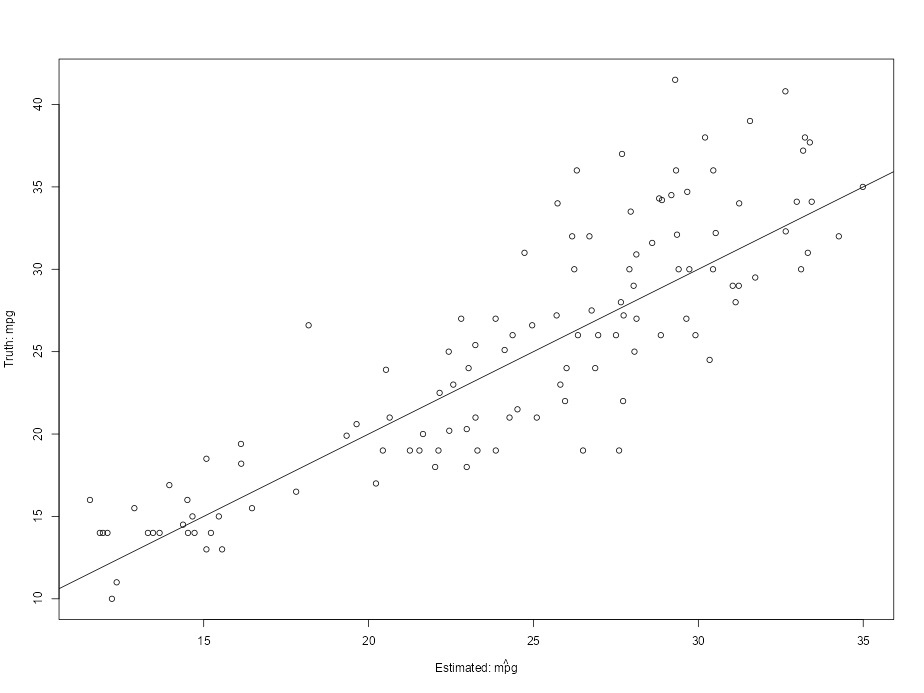

In [5]:
# Generate predictions:
Auto.test$mpg_pred <- predict(fit, newdata = Auto.test)


# Plot estimated values vs truth
plot(
  Auto.test$mpg_pred,
  Auto.test$mpg,
  xlab = expression("Estimated:" ~ hat(mpg)),
  ylab = "Truth: mpg"
)
abline(a = 0, b = 1)

How we assess model performance?

For regression problems- R-squared, MSE, RMSE, MAE...

In [6]:
c(
  rsq = cor(Auto.test$mpg_pred, Auto.test$mpg)^2,
  rmse = sqrt(mean((Auto.test$mpg - Auto.test$mpg_pred)^2))
)

      rsq      rmse 
0.7547369 3.8424988 

Let's do this again, with {tidymodels}.

## (Linear) Regression with {tidymodels} 

We will use the tidymodels ecosystem:
The tidymodels ecosystem is a collection of packages for modeling and machine
learning using tidyverse principles. It includes tools for:

- data splitting
- data preprocessing and feature engineering
- model specification and fitting
- model tuning and evaluation (we will get to this in a few weeks)

(see: https://www.tidymodels.org/)

In [7]:
library(tidymodels)

── Attaching packages ──────────────────────────────────────────────────────────────────────────── tidymodels 1.5.0 ──
✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 
── Conflicts ─────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages


### 1) Split the data

In [9]:
splits <- initial_split(Auto, prop = 0.7) # create a splits object
print(splits) # see the sizes of the sets
Auto.train <- training(splits) # Extract the training set
Auto.test <- testing(splits) # Extract the test set

<Training/Testing/Total>
<274/118/392>


### 2) Specify the model

#### i. Define outcome + predictors

We again use a formula, but inside the `recipe()`

In [10]:
rec <- recipe(mpg ~ origin + weight + horsepower, data = Auto.train)
rec


── Recipe ────────────────────────────────────────────────────────────────────────────────────────────────────────────

── Inputs 
Number of variables by role
outcome:   1
predictor: 3

#### ii. Preprocessing

This is done by adding "steps" to the recipe - how should variables be
processed *prior* to the model fitting.

There are many prepossessing "steps" we can take:
https://recipes.tidymodels.org/reference/index.html
For example, here we want:

In [11]:
rec <- rec |>
  # - origin is a categorical variable, so we need to (1) convert it to a
  # factor, and (2) dummy code it
  step_num2factor(origin, levels = c("American", "European", "Japanese")) |>
  step_dummy(origin) |>
  # - weight is standardized
  step_normalize(weight) |>
  # - adding an interaction between (standardized) weight and horsepower
  step_interact(~ weight:horsepower)

rec


── Recipe ────────────────────────────────────────────────────────────────────────────────────────────────────────────

── Inputs 
Number of variables by role
outcome:   1
predictor: 3

── Operations 
• Factor variables from: origin
• Dummy variables from: origin
• Centering and scaling for: weight
• Interactions with: weight:horsepower

This is quite verbose compared to the formula, but will come in handy with
more complicated steps and models.

Right now, the recipe is just a list of general instructions. To get a recipe
with specific instruction steps, we need to train the recipe. In the
tidymodels terminology, the process of training a recipe is called
"preparing":

In [12]:
prep(rec)


── Recipe ────────────────────────────────────────────────────────────────────────────────────────────────────────────

── Inputs 
Number of variables by role
outcome:   1
predictor: 3

── Training information 
Training data contained 274 data points and no incomplete rows.

── Operations 
• Factor variables from: origin | Trained
• Dummy variables from: origin | Trained
• Centering and scaling for: weight | Trained
• Interactions with: weight:horsepower | Trained

We can then use the "prepared" recipe to "bake" some data into the shape we
want (compare this to the model matrix above):

In [13]:
prep(rec) |> bake(new_data = Auto.train)

# A tibble: 274 × 6
     weight horsepower   mpg origin_European origin_Japanese weight_x_horsepower
      <dbl>      <dbl> <dbl>           <dbl>           <dbl>               <dbl>
 1  1.83           150  16                 0               0             274.   
 2 -1.19            70  26                 0               0             -83.2  
 3 -0.492           75  31.3               0               1             -36.9  
 4 -0.0512         100  20                 0               0              -5.12 
 5 -1.40            65  31                 0               1             -91.3  
 6 -0.981           52  44                 1               0             -51.0  
 7 -0.00849         67  36.4               1               0              -0.569
 8  0.543          110  22.4               0               0              59.7  
 9  0.922          140  19.4               0               0             129.   
10  1.22           145  13                 0               0             177.   
# ℹ 264 

#### iii. Define the type of model

In `{tidymodels}` this stage is separate from the model fitting. We define a
model specification (or model "spec") using one of the functions from the
`{parsnip}` package (or one if its extensions).

In [14]:
linreg_spec <- linear_reg(mode = "regression", engine = "lm")

This spec will then be "translated" to use the correct underlying fitting
function:

In [15]:
translate(linreg_spec)

Linear Regression Model Specification (regression)

Computational engine: lm 

Model fit template:
stats::lm(formula = missing_arg(), data = missing_arg(), weights = missing_arg())

There are many different ways to fit a linear regression - we will learn some
of them over the coming weeks. These different ways are controlled by
different "engines" that can be used to fit the same model spec.

In [16]:
show_engines("linear_reg")

# A tibble: 9 × 2
  engine   mode               
  <chr>    <chr>              
1 lm       regression         
2 glm      regression         
3 glmnet   regression         
4 stan     regression         
5 spark    regression         
6 keras    regression         
7 keras3   regression         
8 brulee   regression         
9 quantreg quantile regression

Finally, we can combine the recipe and the model spec to a workflow - together
they tell us how data *should* be used to fit a model.

In [17]:
linreg_wf <- workflow(preprocessor = rec, spec = linreg_spec)
linreg_wf

══ Workflow ══════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: linear_reg()

── Preprocessor ──────────────────────────────────────────────────────────────────────────────────────────────────────
4 Recipe Steps

• step_num2factor()
• step_dummy()
• step_normalize()
• step_interact()

── Model ─────────────────────────────────────────────────────────────────────────────────────────────────────────────
Linear Regression Model Specification (regression)

Computational engine: lm 


### 3) Fitting the model

Fitting the model is as easy as passing the workflow and some training data
to the `fit()` function:

In [18]:
linreg_fit <- fit(linreg_wf, data = Auto.train)

We can extract the underlying model object:

In [19]:
linreg_engine <- extract_fit_engine(linreg_fit)
print(class(linreg_engine))

# compare to:
cbind(
  "{tidymodels}" = coef(linreg_engine),
  "stats::lm" = coef(fit)[c(1, 4, 5, 2, 3, 6)]
)

[1] "lm"


                    {tidymodels}   stats::lm
(Intercept)          34.01973701 30.13301009
weight               -8.68197213 -7.43612983
horsepower           -0.12170401 -0.08658132
origin_European       0.91266804  0.83006576
origin_Japanese       1.90123106  2.59861273
weight_x_horsepower   0.05276316  0.03636455

(Why aren't these exactly the same? How is this related to bias or variance?)

### 4) Evaluate the model

In [24]:
# Generate predictions:
predict(linreg_fit, new_data = Auto.test) |>head() # generates a data frame

# A tibble: 6 × 1
  .pred
  <dbl>
1  15.3
2  12.8
3  12.1
4  12.1
5  12.3
6  13.5

In [23]:
predict(linreg_fit, new_data = Auto.test, type = "raw") |>head() # generates a vector

       1        2        3        4        5        6 
15.32830 12.81911 12.09171 12.13062 12.31801 13.53681 

In [22]:
# Or we can "augment" a dataset - add predictions to it
Auto.test_predictions <- augment(linreg_fit, new_data = Auto.test)
head(Auto.test_predictions)

# A tibble: 6 × 11
  .pred .resid   mpg cylinders displacement horsepower weight acceleration  year origin name               
  <dbl>  <dbl> <dbl>     <dbl>        <dbl>      <dbl>  <dbl>        <dbl> <dbl>  <dbl> <fct>              
1  15.3   2.67    18         8          318        150   3436         11      70      1 plymouth satellite 
2  12.8   2.18    15         8          429        198   4341         10      70      1 ford galaxie 500   
3  12.1   1.91    14         8          454        220   4354          9      70      1 chevrolet impala   
4  12.1   1.87    14         8          440        215   4312          8.5    70      1 plymouth fury iii  
5  12.3   2.68    15         8          390        190   3850          8.5    70      1 amc ambassador dpl 
6  13.5   1.46    15         8          383        170   3563         10      70      1 dodge challenger se

In either case, the test set is preprocessed according to the recipe, and
predictions are then made.


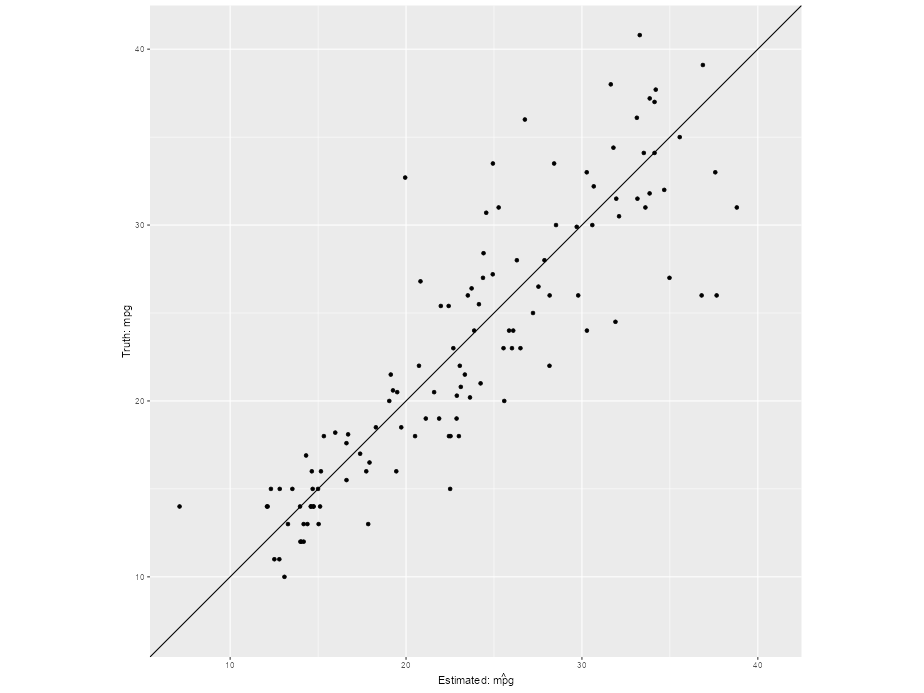

In [25]:
ggplot(Auto.test_predictions, aes(.pred, mpg)) +
  geom_abline() +
  geom_point() +
  coord_obs_pred() +
  labs(x = expression("Estimated:" ~ hat(mpg)), y = "Truth: mpg")

In [26]:
# Performance metrics
Auto.test_predictions |> rsq(mpg, .pred)
Auto.test_predictions |> rmse(mpg, .pred)

# or define a metric est:
mset_reg <- metric_set(rsq, rmse, mae)
Auto.test_predictions |> mset_reg(mpg, .pred)

# A tibble: 3 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 rsq     standard       0.766
2 rmse    standard       3.81 
3 mae     standard       2.87 